**Import the necessary libraries**

In [ ]:
!pip install opencv-python-headless
!pip install ezdxf

In [3]:
import cv2
import numpy as np
import ezdxf
from google.colab import files
import matplotlib.pyplot as plt

**Upload The Signs Face Images**


In [ ]:
uploaded = files.upload()

**Vectorize The Uploaded Images**

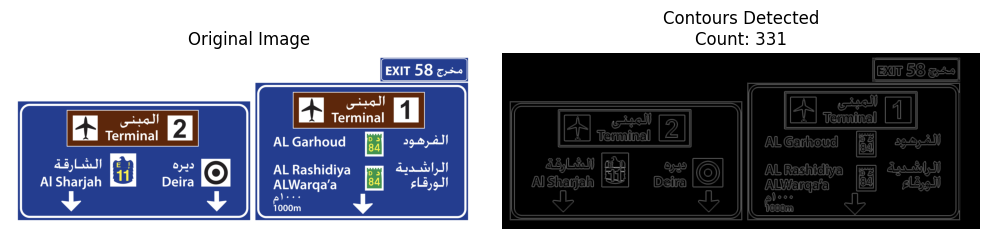

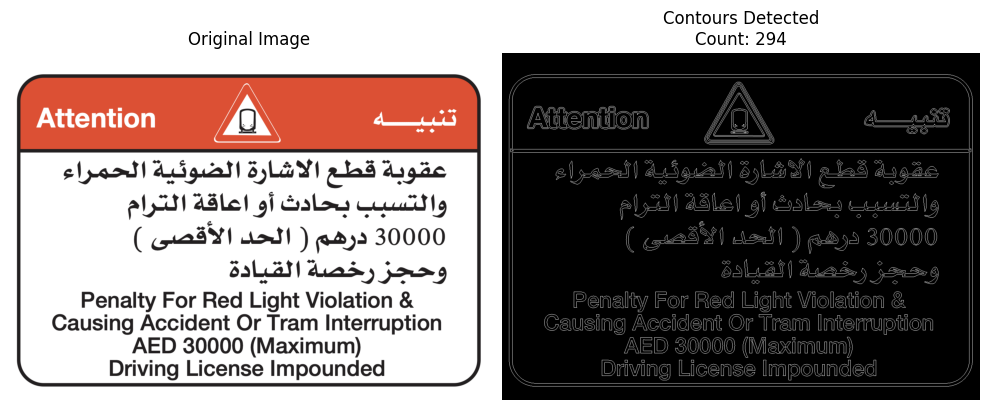

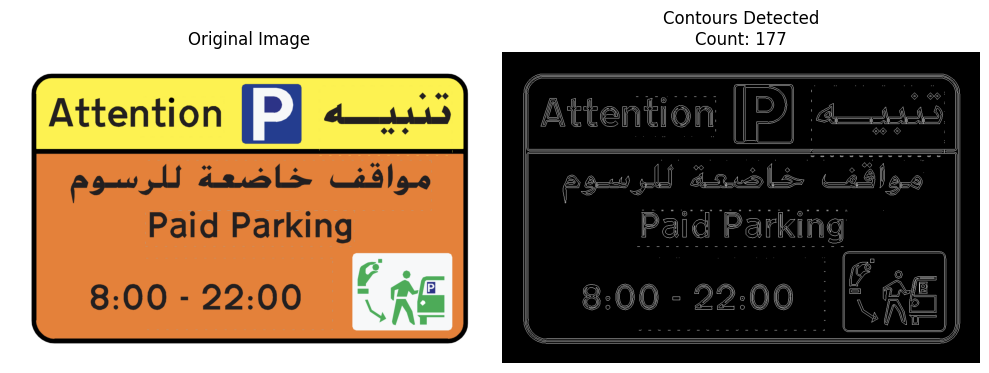

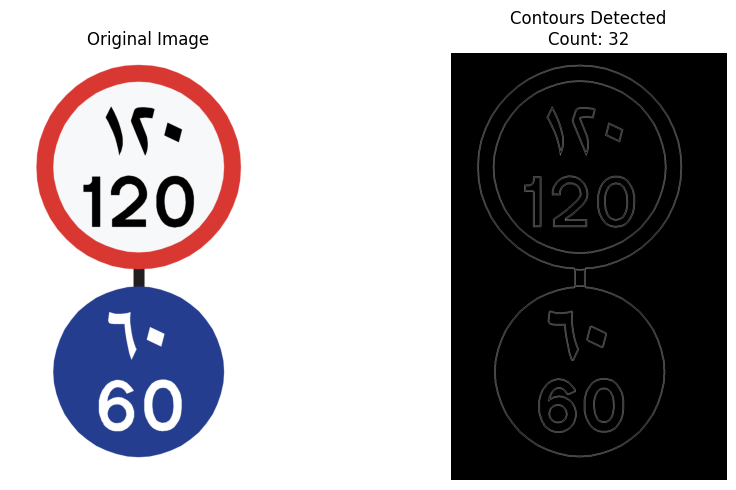

In [63]:
# Load image and convert to binary
file_names = list(uploaded.keys())
original_images = {}
img_cnt_dict={}

for img in file_names:
  imgname = img
  img = cv2.imread(img)
  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  _, binary = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)

  # Find contours
  contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

  # adaptive threshold
  binary = cv2.adaptiveThreshold(gray, 255,
                                cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                cv2.THRESH_BINARY_INV,
                                11, 2)

  # Detect contours
  contours, _ = cv2.findContours(binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)


  # Draw detected contours
  canvas = np.zeros_like(gray)
  cv2.drawContours(canvas, contours, -1, (255), 1)


  # Filter out small noise ((if it's needed _ then replace the contours with filtered
  # in list passed to the dxf))
  min_area = 50
  filtered_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]
  img_cnt_dict[imgname] = contours


  # Show original + contour side by side
  fig, axs = plt.subplots(1, 2, figsize=(10, 5))

  # Original image (in color)
  axs[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
  axs[0].set_title("Original Image")
  axs[0].axis("off")

  # Contour canvas (grayscale)
  axs[1].imshow(canvas, cmap='gray')
  axs[1].set_title(f"Contours Detected\nCount: {len(filtered_contours)}")
  axs[1].axis("off")

  plt.tight_layout()
  plt.show()

**Export Vectors To DXF Format**

In [ ]:
# Create DXF and add contours as polylines

for img, filtered_contours in img_cnt_dict.items():
  doc = ezdxf.new()
  msp = doc.modelspace()
  height = canvas.shape[0]

  for cnt in filtered_contours:
      points = [(int(p[0][0]), height - int(p[0][1])) for p in cnt]
      if len(points) > 1:
          msp.add_lwpolyline(points, close=True)

  # Save and download
  output_name = f"vectorized_{img}.dxf"
  doc.saveas(output_name)
  files.download(output_name)
